# Part 4 — Load the trained AraBERT model from Google Drive

In [ ]:
import subprocess
import sys
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "transformers==5.16.1", "datasets", "arabert", "scikit-learn",
    "matplotlib", "pandas", "google-api-python-client", "safetensors",
])


0

## 1. Download the saved model from Drive — no training

In [ ]:
from pathlib import Path
import io
from google.colab import auth
import google.auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

auth.authenticate_user()
credentials, _ = google.auth.default()
drive_service = build("drive", "v3", credentials=credentials)
MODEL_DIR = Path("/content/arabert-arsas-drive")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Exact file IDs and sizes verified in the shared Drive folder.
model_files = {
    "config.json": ("1WyFylZJCBOwWYwj3bBEj1n7niwRkQWwA", 898),
    "model.safetensors": ("1mLGTPzZXAp4zCi6RXmaLUpK5r5ZuWFwU", 540806148),
    "tokenizer.json": ("1oghvPbprQbcsc899-OJzaOsLsZYTEabP", 1777127),
    "tokenizer_config.json": ("17GxKOFQwF8JxgkovAfw9BPANoZGuCZmd", 480),
}
for filename, (file_id, expected_size) in model_files.items():
    destination = MODEL_DIR / filename
    if destination.exists() and destination.stat().st_size == expected_size:
        print("Already downloaded:", filename)
        continue
    partial = destination.with_suffix(destination.suffix + ".part")
    request = drive_service.files().get_media(fileId=file_id)
    with io.FileIO(partial, "wb") as stream:
        downloader = MediaIoBaseDownload(stream, request, chunksize=32 * 1024 * 1024)
        done = False
        while not done:
            status, done = downloader.next_chunk(num_retries=3)
            if status:
                print(f"{filename}: {status.progress():.0%}")
    if partial.stat().st_size != expected_size:
        raise RuntimeError(f"Unexpected size for {filename}; verify the Drive file version.")
    partial.replace(destination)
print("Model files ready.")


config.json: 100%
model.safetensors: 6%
model.safetensors: 12%
model.safetensors: 19%
model.safetensors: 25%
model.safetensors: 31%
model.safetensors: 37%
model.safetensors: 43%
model.safetensors: 50%
model.safetensors: 56%
model.safetensors: 62%
model.safetensors: 68%
model.safetensors: 74%
model.safetensors: 81%
model.safetensors: 87%
model.safetensors: 93%
model.safetensors: 99%
model.safetensors: 100%
tokenizer.json: 100%
tokenizer_config.json: 100%
Model files ready.


## 2. Load trained weights, saved labels and tokenizer

In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from arabert.preprocess import ArabertPreprocessor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, local_files_only=True)
inference_model, loading_info = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR, local_files_only=True, use_safetensors=True, output_loading_info=True
)
if loading_info.get("missing_keys") or loading_info.get("mismatched_keys") or loading_info.get("error_msgs"):
    raise RuntimeError(f"Saved weights did not load completely: {loading_info}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inference_model.to(device).eval()
class_map = {int(k): str(v) for k, v in inference_model.config.id2label.items()}
label2id = {v: k for k, v in class_map.items()}
class_ids = sorted(class_map)
class_names = [class_map[i] for i in class_ids]
assert class_ids == list(range(inference_model.config.num_labels))
# The original notebook used v02 (no Farasa), not v2.
arabert_prep = ArabertPreprocessor(model_name="aubmindlab/bert-base-arabertv02")
MAX_LENGTH = 128
print("Device:", device)
print("Saved classes:", class_map)
print("This saved model has 3 classes; its confusion matrix will be 3 x 3.")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Device: cpu
Saved classes: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
This saved model has 3 classes; its confusion matrix will be 3 x 3.


## 3. Arabic inference demo — available immediately after loading the model

In [ ]:
def predict_sentiment(text):
    """Return the predicted class and softmax scores for one Arabic sentence."""
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Please enter a non-empty Arabic sentence.")

    processed_text = arabert_prep.preprocess(text.strip())
    inputs = tokenizer(
        processed_text,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )
    device = next(inference_model.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}
    inference_model.eval()
    with torch.inference_mode():
        logits = inference_model(**inputs).logits
        probabilities = torch.softmax(logits.float(), dim=-1)[0].cpu()

    predicted_id = int(probabilities.argmax().item())
    return {
        "text": text,
        "sentiment": class_map[predicted_id],
        "confidence": float(probabilities[predicted_id]),
        "probabilities": {
            class_map[i]: float(probabilities[i]) for i in class_ids
        },
    }



In [ ]:
from IPython.display import display
demo_texts = [
    "الخدمة ممتازة وأنا سعيدة جدا بالتجربة",
    "التجربة سيئة جدا ولن أكررها مرة أخرى",
    "سيبدأ الاجتماع غدا الساعة العاشرة صباحا",
    "المنتج جميل لكن سعره مرتفع والتوصيل كان سيئا",
]
display(pd.DataFrame([predict_sentiment(t) for t in demo_texts]))
print(predict_sentiment("أنا مبسوطة جدا بالنتيجة"))
# Softmax confidence is a model score, not a guarantee of correctness.
# Mixed sentiment still receives one of the three learned labels.


,text,sentiment,confidence,probabilities
0,الخدمة ممتازة وأنا سعيدة جدا بالتجربة,Positive,0.994816,"{'Negative': 0.0025463970378041267, 'Neutral':..."
1,التجربة سيئة جدا ولن أكررها مرة أخرى,Negative,0.998000,"{'Negative': 0.99800044298172, 'Neutral': 0.00..."
2,سيبدأ الاجتماع غدا الساعة العاشرة صباحا,Neutral,0.997499,"{'Negative': 0.0009802174754440784, 'Neutral':..."
3,المنتج جميل لكن سعره مرتفع والتوصيل كان سيئا,Negative,0.970045,"{'Negative': 0.9700450301170349, 'Neutral': 0...."


{'text': 'أنا مبسوطة جدا بالنتيجة', 'sentiment': 'Positive', 'confidence': 0.9971669316291809, 'probabilities': {'Negative': 0.0012228115228936076, 'Neutral': 0.0016101992223411798, 'Positive': 0.9971669316291809}}


## 4. Reconstruct only the test data


In [ ]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split

raw_dataset = load_dataset(
    "Qanadil/ArSAS_An_Arabic_Speech-Act_and_Sentiment_Corpus_of_Tweets",
    split="train",
)
df = raw_dataset.to_pandas()
text_candidates = ["tweet_text", "Tweet_text", "Tweet_Text", "tweet", "Tweet", "text", "Text"]
text_column = next((c for c in text_candidates if c in df.columns), None)
if text_column is None:
    raise ValueError(f"Tweet column not found: {list(df.columns)}")
# Same cleaning operations and order as Part 1.
df = df[[text_column, "Sentiment_label"]].copy().rename(columns={text_column: "tweet_text"})
df = df.dropna(subset=["tweet_text", "Sentiment_label"]).copy()
df["tweet_text"] = df["tweet_text"].astype(str).str.strip()
df = df[df["tweet_text"] != ""].copy()
df = df.drop_duplicates(subset=["tweet_text"]).reset_index(drop=True)
expected_counts = {"Negative": 7340, "Neutral": 6870, "Positive": 4380}
if len(raw_dataset) != 18678 or df["Sentiment_label"].value_counts().to_dict() != expected_counts:
    raise RuntimeError("Dataset differs from the original notebook counts. Use the original saved test split.")

_, temp_df = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["Sentiment_label"]
)
_, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["Sentiment_label"]
)
test_df = test_df.reset_index(drop=True)
assert len(test_df) == 1859
assert test_df["Sentiment_label"].value_counts().to_dict() == {"Negative": 734, "Neutral": 687, "Positive": 438}
test_df["label"] = test_df["Sentiment_label"].map(label2id)
if test_df["label"].isna().any():
    raise ValueError("Test labels do not match the trained model.")
test_df["processed_text"] = test_df["tweet_text"].apply(arabert_prep.preprocess)
print("Reconstructed test samples:", len(test_df))
print("Counts match the notebook; row identity still depends on unchanged source data/order.")


README.md:   0%|          | 0.00/1.61k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.82MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/18678 [00:00<?, ? examples/s]

Reconstructed test samples: 1859
Counts match the notebook; row identity still depends on unchanged source data/order.


## 5. Batched test predictions — inference only

In [9]:
from tqdm.auto import tqdm

BATCH_SIZE = 32 if device.type == "cuda" else 8
predicted_batches = []
inference_model.eval()
with torch.inference_mode():
    for start in tqdm(range(0, len(test_df), BATCH_SIZE), desc="Evaluating"):
        texts = test_df["processed_text"].iloc[start:start + BATCH_SIZE].tolist()
        inputs = tokenizer(
            texts, padding="max_length", truncation=True,
            max_length=MAX_LENGTH, return_tensors="pt",
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        logits = inference_model(**inputs).logits
        predicted_batches.append(logits.argmax(dim=-1).cpu().numpy())
y_pred = np.concatenate(predicted_batches)
y_true = test_df["label"].to_numpy(dtype=int)


Evaluating:   0%|          | 0/233 [00:00<?, ?it/s]

## 6. Accuracy, Macro-F1, classification report and confusion matrix

Test Accuracy: 0.8607
Test Macro-F1: 0.8534
              precision    recall  f1-score   support

    Negative     0.8913    0.8937    0.8925       734
     Neutral     0.8662    0.8574    0.8617       687
    Positive     0.8014    0.8105    0.8059       438

    accuracy                         0.8607      1859
   macro avg     0.8529    0.8539    0.8534      1859
weighted avg     0.8608    0.8607    0.8607      1859



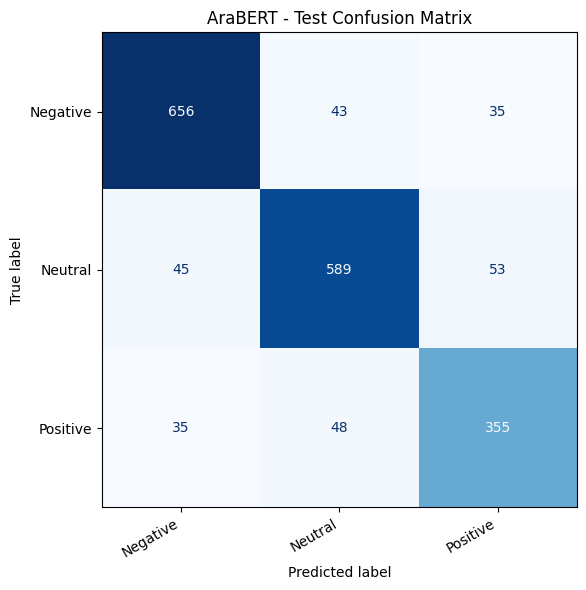

In [10]:
test_accuracy = accuracy_score(y_true, y_pred)
test_macro_f1 = f1_score(
    y_true, y_pred, labels=class_ids, average="macro", zero_division=0
)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro-F1: {test_macro_f1:.4f}")

# %% 3. Per-class precision, recall and F1
print(classification_report(
    y_true, y_pred,
    labels=class_ids,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

# %% 4. Confusion matrix (rows = true labels, columns = predicted labels)
cm = confusion_matrix(y_true, y_pred, labels=class_ids)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap="Blues", values_format="d", colorbar=False
)
ax.set_title("AraBERT - Test Confusion Matrix")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
plt.show()

